In [1]:
# 1. Install dependencies
# 2. Initialize Spark
# 3. Load CSV from GitHub (pandas → Spark)
# 4. Preprocessing (clean, date parse, feature engineering)
# 5. Save Silver parquet to /content/silver
# 6. EDA (summary stats, visualizations)
# 7. Create Gold label (top 25% ROI)
# 8. Save Gold parquet to /content/gold

# Phase 2

## 1. Install dependencies

In [2]:
!pip install pyspark --quiet

## 2. Imports

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from functools import reduce
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Initialize Spark session

In [4]:
spark = SparkSession.builder \
    .appName("CampaignAnalysis") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.ansi.enabled", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/05 10:47:37 WARN Utils: Your hostname, Shubhs-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 100.70.79.150 instead (on interface en0)
26/03/05 10:47:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 10:47:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


## GitHub URLs + helper functions

In [5]:
# GitHub raw URLs for CSV files
urls = {
    "nykaa":   "data/nykaa_campaign_data.csv",
    "purplle": "data/purplle_campaign_data.csv",
    "tira":    "data/tira_campaign_data.csv"
}

# Silver and Gold parquet save paths
silver_path = "/data/marketing_silver_parquet"
gold_path   = "/data/marketing_gold_parquet"

# Normalize column names: lowercase, replace non-alphanumerics with underscore
def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

# Parse dates
# handles both dd-MM-yyyy and MM/dd/yyyy formats
def parse_dates(pdf: pd.DataFrame, col: str = "date") -> pd.DataFrame:
    def try_parse(val):
        if pd.isnull(val):
            return None
        s = str(val).strip()
        # dd-MM-yyyy (e.g. 19-10-2024)
        try:
            return pd.to_datetime(s, format="%d-%m-%Y")
        except:
            pass
        # MM/dd/yyyy (e.g. 10/19/2024)
        try:
            return pd.to_datetime(s, format="%m/%d/%Y")
        except:
            pass
        return None
    pdf[col] = pdf[col].apply(try_parse)
    return pdf

# Read CSV from GitHub via pandas, parse dates, convert to Spark DataFrame
def read_campaign(url: str, brand: str):
    pdf = pd.read_csv(url)
    pdf.columns = [normalize_colname(c) for c in pdf.columns]
    pdf = parse_dates(pdf, "date")
    pdf["brand_source"] = brand
    df = spark.createDataFrame(pdf)
    return df

# Add missing columns as nulls to align schemas
def align_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(all_cols)

# safe_div
# avoid division-by-zero (returns null if denominator <= 0 or null)
def safe_div(num_col, den_col):
    return F.when(
        (den_col.isNotNull()) & (den_col > 0) & (num_col.isNotNull()),
        num_col / den_col
    )

## 5. Ingest and union all sources

In [6]:
# Load all 3 brand CSVs and union into single DataFrame
dfs = [read_campaign(url, brand) for brand, url in urls.items()]
all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))

dfs_aligned = [align_cols(d, all_cols) for d in dfs]
df_all = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs_aligned)

# Drop exact duplicate rows
df_all = df_all.dropDuplicates()

df_all.printSchema()
print(f"Total rows: {df_all.count():,}")

root
 |-- acquisition_cost: double (nullable = true)
 |-- brand_source: string (nullable = true)
 |-- campaign_id: string (nullable = true)
 |-- campaign_type: string (nullable = true)
 |-- channel_used: string (nullable = true)
 |-- clicks: long (nullable = true)
 |-- conversions: long (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- duration: long (nullable = true)
 |-- engagement_score: double (nullable = true)
 |-- impressions: long (nullable = true)
 |-- language: string (nullable = true)
 |-- leads: long (nullable = true)
 |-- revenue: long (nullable = true)
 |-- roi: double (nullable = true)
 |-- target_audience: string (nullable = true)



Total rows: 166,665


## 6. Basic cleaning: nulls, whitespace, negative values

In [7]:
# Fill nulls in string columns with "Unknown"
string_cols = [c for c, t in df_all.dtypes if t == "string"]
df_all = df_all.fillna({c: "Unknown" for c in string_cols})

# Trim whitespace in string columns
for c in string_cols:
    df_all = df_all.withColumn(c, F.trim(F.col(c)))

# Replace negative values with null for non-negative numeric columns
nonneg_cols = [c for c, t in df_all.dtypes
               if t in ("int", "bigint", "double", "float", "long")
               and c not in ("roi",)]
for c in nonneg_cols:
    df_all = df_all.withColumn(
        c, F.when(F.col(c) < 0, None).otherwise(F.col(c))
    )

print("Cleaning done.")

Cleaning done.


## 7. Feature engineering: KPI and funnel metrics

In [8]:
# Compute marketing KPIs and funnel conversion metrics
df_feat = (df_all
    .withColumn("ctr",          safe_div(F.col("clicks"),           F.col("impressions")))
    .withColumn("lead_rate",    safe_div(F.col("leads"),            F.col("clicks")))
    .withColumn("lead_to_conv", safe_div(F.col("conversions"),      F.col("leads")))
    .withColumn("click_to_conv",safe_div(F.col("conversions"),      F.col("clicks")))
    .withColumn("cpc",          safe_div(F.col("acquisition_cost"), F.col("clicks")))
    .withColumn("cpa",          safe_div(F.col("acquisition_cost"), F.col("conversions")))
    .withColumn("roas",         safe_div(F.col("revenue"),          F.col("acquisition_cost")))
    .withColumn("rpm",          safe_div(F.col("revenue").cast("double") * 1000, F.col("impressions")))
)

# Clip funnel ratios to [0, 1]
df_feat = (df_feat
    .withColumn("ctr",          F.when((F.col("ctr") < 0)          | (F.col("ctr") > 1),          None).otherwise(F.col("ctr")))
    .withColumn("lead_rate",    F.when((F.col("lead_rate") < 0)    | (F.col("lead_rate") > 1),    None).otherwise(F.col("lead_rate")))
    .withColumn("lead_to_conv", F.when((F.col("lead_to_conv") < 0) | (F.col("lead_to_conv") > 1), None).otherwise(F.col("lead_to_conv")))
    .withColumn("click_to_conv",F.when((F.col("click_to_conv") < 0)| (F.col("click_to_conv") > 1),None).otherwise(F.col("click_to_conv")))
)

# Preview KPI columns
df_feat.select(
    "brand_source", "impressions", "clicks", "leads", "conversions",
    "ctr", "lead_rate", "lead_to_conv", "click_to_conv", "cpc", "cpa", "roas"
).show(10, truncate=False)

+------------+-----------+------+-----+-----------+--------------------+-------------------+-------------------+-------------------+--------------------+-------------------+------------------+
|brand_source|impressions|clicks|leads|conversions|ctr                 |lead_rate          |lead_to_conv       |click_to_conv      |cpc                 |cpa                |roas              |
+------------+-----------+------+-----+-----------+--------------------+-------------------+-------------------+-------------------+--------------------+-------------------+------------------+
|nykaa       |91801      |3321  |1971 |1357       |0.03617607651332774 |0.5934959349593496 |0.6884830035514967 |0.40861186389641674|0.054450466726889496|0.13325718496683864|5785.8043466239005|
|nykaa       |15536      |2182  |952  |755        |0.14044799176107106 |0.43629697525206235|0.7930672268907563 |0.346012832263978  |0.04152153987167736 |0.12               |2175.0            |
|nykaa       |31729      |2418  |77

## 8. Save Silver layer

In [9]:
# Save cleaned + feature-engineered dataset as Silver parquet
df_feat.write.mode("overwrite").parquet(silver_path)

# Reload Silver and register as temp view for Spark SQL
df_silver = spark.read.parquet(silver_path)
df_silver.createOrReplaceTempView("marketing_silver")

df_silver.printSchema()
print(f"Silver saved: {df_silver.count():,} rows")

26/03/05 10:47:52 ERROR FileOutputCommitter: Mkdirs failed to create file:/data/marketing_silver_parquet/_temporary/0
26/03/05 10:47:52 ERROR Utils: Aborting task
java.io.IOException: Mkdirs failed to create file:/data/marketing_silver_parquet/_temporary/0/_temporary/attempt_20260305104752663437530894312138_0011_m_000000_100 (exists=false, cwd=file:/Users/shubhvaishnav/Desktop/590/590)
	at org.apache.hadoop.fs.ChecksumFileSystem.create(ChecksumFileSystem.java:774)
	at org.apache.hadoop.fs.ChecksumFileSystem.create(ChecksumFileSystem.java:759)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1233)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1210)
	at org.apache.parquet.hadoop.util.HadoopOutputFile.create(HadoopOutputFile.java:82)
	at org.apache.parquet.hadoop.ParquetFileWriter.<init>(ParquetFileWriter.java:475)
	at org.apache.parquet.hadoop.ParquetFileWriter.<init>(ParquetFileWriter.java:407)
	at org.apache.parquet.hadoop.ParquetOutputFormat.getRecordWriter(Parq

Py4JJavaError: An error occurred while calling o516.parquet.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 11.0 failed 1 times, most recent failure: Lost task 0.0 in stage 11.0 (TID 100) (100.70.79.150 executor driver): java.io.IOException: Mkdirs failed to create file:/data/marketing_silver_parquet/_temporary/0/_temporary/attempt_20260305104752663437530894312138_0011_m_000000_100 (exists=false, cwd=file:/Users/shubhvaishnav/Desktop/590/590)
	at org.apache.hadoop.fs.ChecksumFileSystem.create(ChecksumFileSystem.java:774)
	at org.apache.hadoop.fs.ChecksumFileSystem.create(ChecksumFileSystem.java:759)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1233)
	at org.apache.hadoop.fs.FileSystem.create(FileSystem.java:1210)
	at org.apache.parquet.hadoop.util.HadoopOutputFile.create(HadoopOutputFile.java:82)
	at org.apache.parquet.hadoop.ParquetFileWriter.<init>(ParquetFileWriter.java:475)
	at org.apache.parquet.hadoop.ParquetFileWriter.<init>(Pa

# Phase 3

## 1. Summary statistics

In [ ]:
# Summary statistics for all numeric columns
df_silver.summary().show(truncate=False)

spark.sql("""
SELECT
    COUNT(*)            AS total_rows,
    ROUND(AVG(clicks), 2)       AS avg_clicks,
    ROUND(AVG(impressions), 2)  AS avg_impressions,
    ROUND(AVG(conversions), 2)  AS avg_conversions,
    ROUND(AVG(ctr), 4)          AS avg_ctr,
    ROUND(AVG(roi), 4)          AS avg_roi
FROM marketing_silver
""").show()

+-------+------------------+------------+-----------+-------------+----------------------------+-----------------+-----------------+----------------+------------------+------------------+------------------+--------+------------------+------------------+------------------+----------------+--------------------+-------------------+-------------------+-------------------+--------------------+---------------------+-------------------+-----------------+
|summary|acquisition_cost  |brand_source|campaign_id|campaign_type|channel_used                |clicks           |conversions      |customer_segment|duration          |engagement_score  |impressions       |language|leads             |revenue           |roi               |target_audience |ctr                 |lead_rate          |lead_to_conv       |click_to_conv      |cpc                 |cpa                  |roas               |rpm              |
+-------+------------------+------------+-----------+-------------+----------------------------+

## 2. Feature distributions

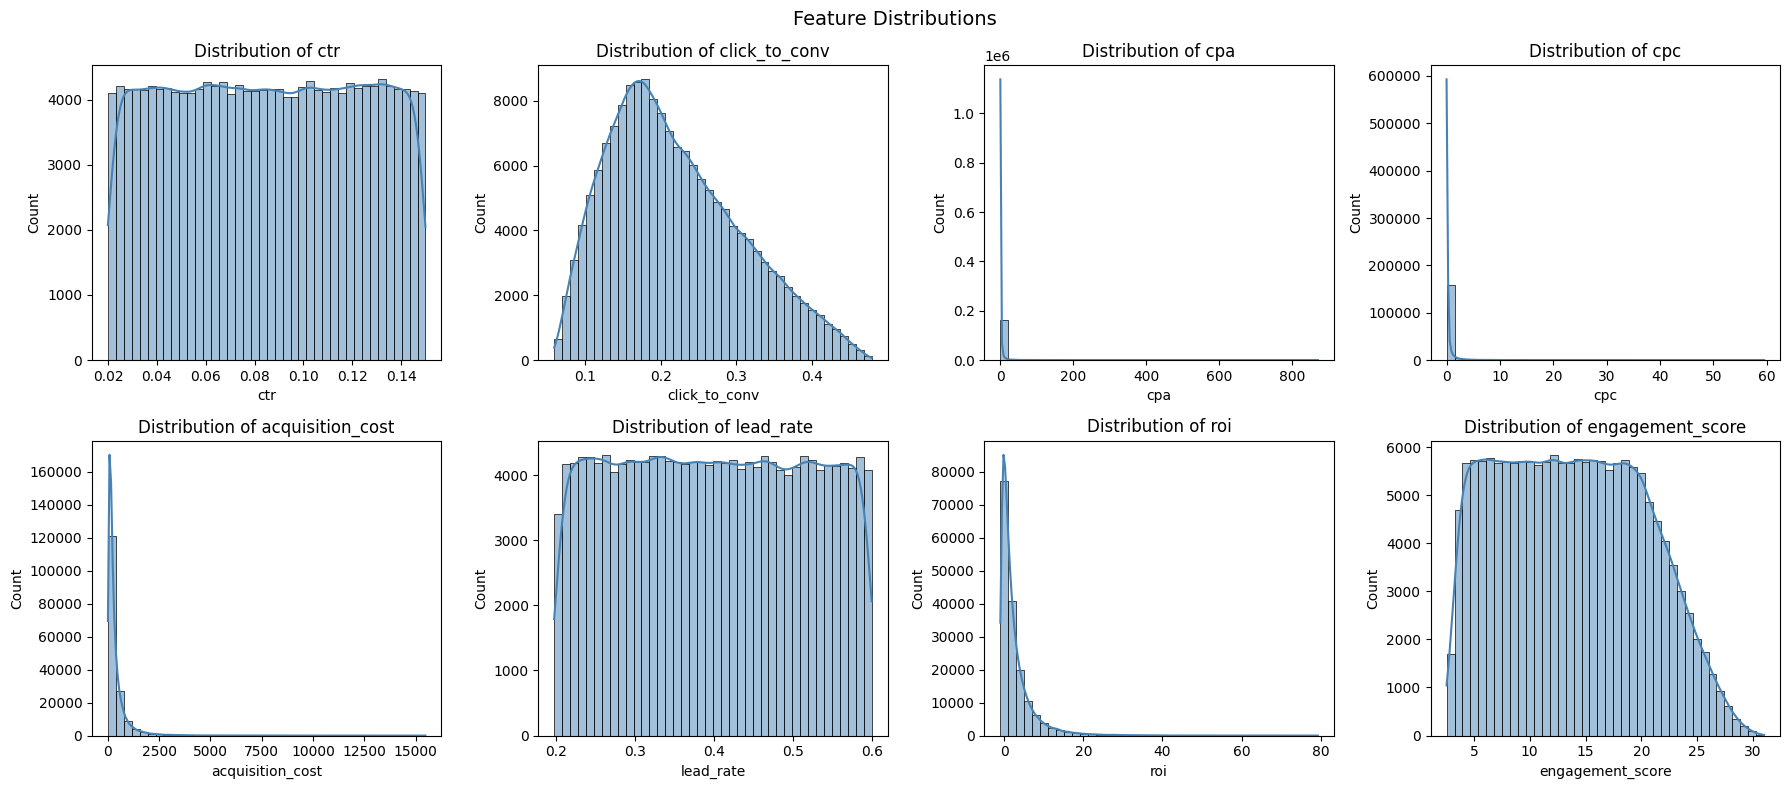

In [ ]:
# Collect sample for visualization
pdf = (df_silver
    .select("ctr", "click_to_conv", "cpa", "cpc",
            "acquisition_cost", "lead_rate", "roi", "engagement_score")
    .dropna()
    .toPandas()
)

# Plot distribution of each KPI feature
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features = ["ctr", "click_to_conv", "cpa", "cpc",
            "acquisition_cost", "lead_rate", "roi", "engagement_score"]

for ax, col in zip(axes.flat, features):
    sns.histplot(pdf[col], kde=True, ax=ax, bins=40, color="steelblue")
    ax.set_title(f"Distribution of {col}")

plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Correlation heatmap

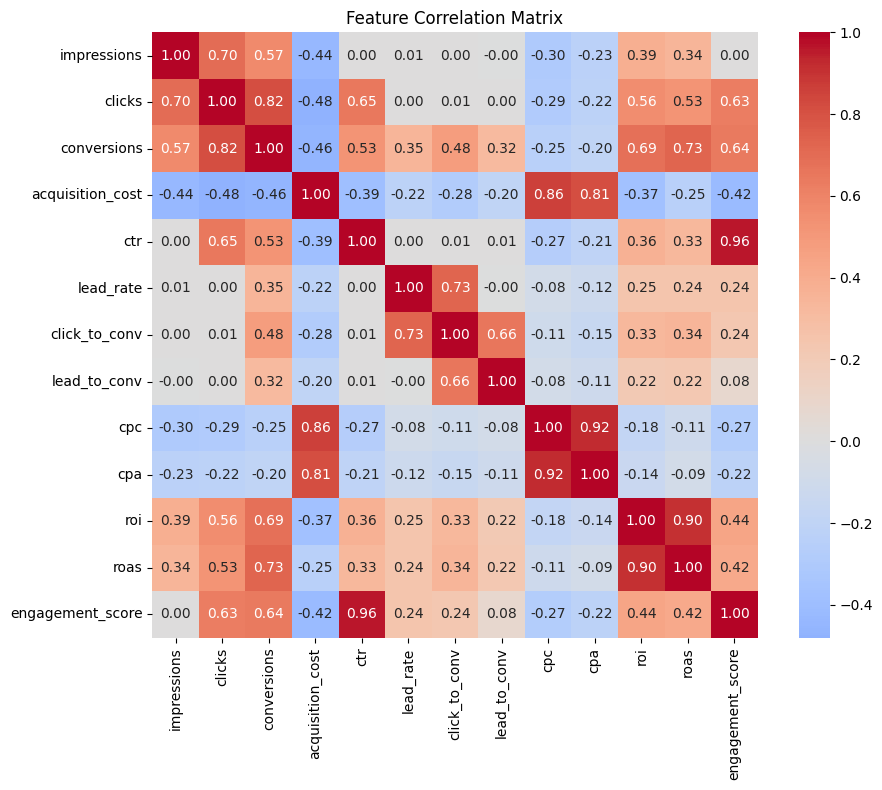

In [ ]:
# Correlation matrix to detect multicollinearity among numeric features
corr_cols = ["impressions", "clicks", "conversions", "acquisition_cost",
             "ctr", "lead_rate", "click_to_conv", "lead_to_conv",
             "cpc", "cpa", "roi", "roas", "engagement_score"]

corr_matrix = (df_silver
    .select(corr_cols)
    .dropna()
    .toPandas()
    .corr()
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Monthly ROI trend

+------------+-------------------+-------------------+-----------+
|brand_source|         start_date|           end_date|n_campaigns|
+------------+-------------------+-------------------+-----------+
|       nykaa|2024-07-01 00:00:00|2025-06-24 00:00:00|      55555|
|     purplle|2024-07-01 00:00:00|2025-06-24 00:00:00|      55555|
|        tira|2024-07-01 00:00:00|2025-06-24 00:00:00|      55555|
+------------+-------------------+-------------------+-----------+



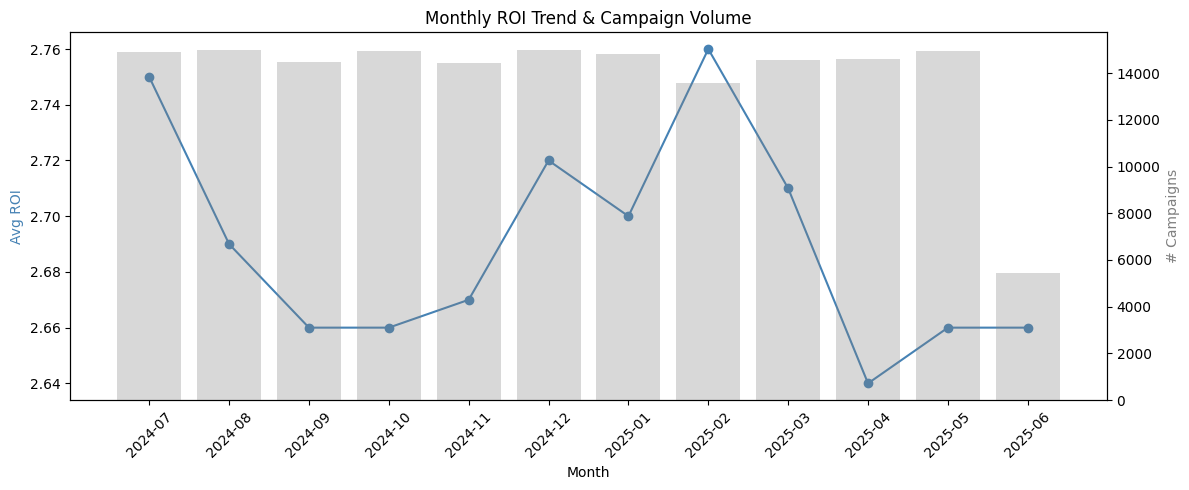

In [ ]:
# Date range check per brand
spark.sql("""
SELECT
    brand_source,
    MIN(date) AS start_date,
    MAX(date) AS end_date,
    COUNT(*) AS n_campaigns
FROM marketing_silver
GROUP BY brand_source
ORDER BY brand_source
""").show()

# Monthly average ROI trend with campaign volume
monthly_trend = spark.sql("""
SELECT
    DATE_FORMAT(date, 'yyyy-MM') AS month,
    ROUND(AVG(roi), 2)           AS avg_roi,
    ROUND(AVG(ctr), 4)           AS avg_ctr,
    COUNT(*)                     AS n_campaigns
FROM marketing_silver
GROUP BY DATE_FORMAT(date, 'yyyy-MM')
ORDER BY month
""").toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_trend["month"], monthly_trend["avg_roi"],
         marker="o", color="steelblue", label="Avg ROI")
ax1.set_xlabel("Month")
ax1.set_ylabel("Avg ROI", color="steelblue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.bar(monthly_trend["month"], monthly_trend["n_campaigns"],
        alpha=0.3, color="gray", label="# Campaigns")
ax2.set_ylabel("# Campaigns", color="gray")

plt.title("Monthly ROI Trend & Campaign Volume")
fig.tight_layout()
plt.show()

## 5. Performance by campaign type

In [ ]:
# Average ROI, CTR, conversion rate, and CPA by campaign type
spark.sql("""
SELECT
    campaign_type,
    COUNT(*)                     AS n_campaigns,
    ROUND(AVG(roi), 2)           AS avg_roi,
    ROUND(AVG(ctr), 4)           AS avg_ctr,
    ROUND(AVG(click_to_conv), 4) AS avg_conversion,
    ROUND(AVG(cpa), 2)           AS avg_cpa
FROM marketing_silver
GROUP BY campaign_type
ORDER BY avg_roi DESC
""").show(truncate=False)

+-------------+-----------+-------+-------+--------------+-------+
|campaign_type|n_campaigns|avg_roi|avg_ctr|avg_conversion|avg_cpa|
+-------------+-----------+-------+-------+--------------+-------+
|Paid Ads     |33283      |2.71   |0.0851 |0.2195        |2.02   |
|Social Media |33179      |2.71   |0.0853 |0.2187        |2.05   |
|Email        |33493      |2.69   |0.0848 |0.22          |2.11   |
|SEO          |33207      |2.69   |0.0847 |0.22          |2.09   |
|Influencer   |33503      |2.65   |0.0853 |0.2191        |2.1    |
+-------------+-----------+-------+-------+--------------+-------+



## 6. Channel performance analysis

In [ ]:
# Explode multi-value channel_used column and aggregate by channel
df_channel = (df_silver
    .withColumn("channel", F.explode(F.split(F.col("channel_used"), ",")))
    .withColumn("channel", F.trim(F.col("channel")))
)

df_channel.groupBy("channel") \
    .agg(
        F.count("*").alias("n"),
        F.round(F.avg("roi"), 4).alias("avg_roi"),
        F.round(F.avg("ctr"), 4).alias("avg_ctr")
    ) \
    .orderBy(F.desc("avg_roi")) \
    .show(truncate=False)

+---------+-----+-------+-------+
|channel  |n    |avg_roi|avg_ctr|
+---------+-----+-------+-------+
|Email    |55590|2.7298 |0.0853 |
|Instagram|55599|2.7223 |0.0853 |
|Google   |55576|2.6887 |0.0847 |
|Facebook |55578|2.6798 |0.0848 |
|WhatsApp |55455|2.6776 |0.0852 |
|YouTube  |55583|2.6696 |0.0848 |
+---------+-----+-------+-------+



## 7. Save Gold layer

In [ ]:
# Define binary target label
# top 25% ROI = high-performing campaign (1), else (0)
q75 = df_silver.approxQuantile("roi", [0.75], 0.01)[0]
print(f"75th percentile ROI (threshold): {q75}")

df_gold = df_silver.withColumn(
    "label",
    F.when(F.col("roi") >= q75, 1).otherwise(0)
)

# Save Gold parquet
df_gold.write.mode("overwrite").parquet(gold_path)

# Reload and register as temp view
df_gold = spark.read.parquet(gold_path)
df_gold.createOrReplaceTempView("marketing_gold")

# Label distribution check
df_gold.groupBy("label").count().orderBy("label").show()
print(f"Gold saved: {df_gold.count():,} rows")

75th percentile ROI (threshold): 3.52
+-----+------+
|label| count|
+-----+------+
|    0|124268|
|    1| 42397|
+-----+------+

Gold saved: 166,665 rows


# Phase 4

## 1. Install dependencies

In [ ]:
!pip install pyspark --quiet

## 2. Imports

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from functools import reduce
import re
import pandas as pd
import matplotlib.pyplot as plt

## 3. Initialize Spark session

In [ ]:
spark = SparkSession.builder \
    .appName("CampaignClassification") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.ansi.enabled", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.0.2


## 4. GitHub URLs + helper functions

In [ ]:
# GitHub raw URLs for CSV files
urls = {
    "nykaa":   "data/nykaa_campaign_data.csv",
    "purplle": "data/purplle_campaign_data.csv",
    "tira":    "data/tira_campaign_data.csv"
}

def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def parse_dates(pdf: pd.DataFrame, col: str = "date") -> pd.DataFrame:
    def try_parse(val):
        if pd.isnull(val):
            return None
        s = str(val).strip()
        try:
            return pd.to_datetime(s, format="%d-%m-%Y")
        except:
            pass
        try:
            return pd.to_datetime(s, format="%m/%d/%Y")
        except:
            pass
        return None
    pdf[col] = pdf[col].apply(try_parse)
    return pdf

def read_campaign(url: str, brand: str):
    pdf = pd.read_csv(url)
    pdf.columns = [normalize_colname(c) for c in pdf.columns]
    pdf = parse_dates(pdf, "date")
    pdf["brand_source"] = brand
    df = spark.createDataFrame(pdf)
    return df

def align_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(all_cols)

def safe_div(num_col, den_col):
    return F.when(
        (den_col.isNotNull()) & (den_col > 0) & (num_col.isNotNull()),
        num_col / den_col
    )

print("Helper functions ready.")

Helper functions ready.


## 5. Load, clean, and engineer features

In [ ]:
# Load all 3 brand CSVs and union
dfs = [read_campaign(url, brand) for brand, url in urls.items()]
all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))
dfs_aligned = [align_cols(d, all_cols) for d in dfs]
df_all = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs_aligned)
df_all = df_all.dropDuplicates()

# Fill nulls in string columns
string_cols = [c for c, t in df_all.dtypes if t == "string"]
df_all = df_all.fillna({c: "Unknown" for c in string_cols})
for c in string_cols:
    df_all = df_all.withColumn(c, F.trim(F.col(c)))

# Replace negative values with null
nonneg_cols = [c for c, t in df_all.dtypes
               if t in ("int", "bigint", "double", "float", "long")
               and c not in ("roi",)]
for c in nonneg_cols:
    df_all = df_all.withColumn(c, F.when(F.col(c) < 0, None).otherwise(F.col(c)))

# KPI feature engineering
df_feat = (df_all
    .withColumn("ctr",           safe_div(F.col("clicks"),           F.col("impressions")))
    .withColumn("lead_rate",     safe_div(F.col("leads"),            F.col("clicks")))
    .withColumn("lead_to_conv",  safe_div(F.col("conversions"),      F.col("leads")))
    .withColumn("click_to_conv", safe_div(F.col("conversions"),      F.col("clicks")))
    .withColumn("cpc",           safe_div(F.col("acquisition_cost"), F.col("clicks")))
    .withColumn("cpa",           safe_div(F.col("acquisition_cost"), F.col("conversions")))
    .withColumn("roas",          safe_div(F.col("revenue"),          F.col("acquisition_cost")))
    .withColumn("rpm",           safe_div(F.col("revenue").cast("double") * 1000, F.col("impressions")))
)

# Clip funnel ratios to [0, 1]
for col in ["ctr", "lead_rate", "lead_to_conv", "click_to_conv"]:
    df_feat = df_feat.withColumn(
        col, F.when((F.col(col) < 0) | (F.col(col) > 1), None).otherwise(F.col(col))
    )

print(f"Data loaded: {df_feat.count():,} rows")

Data loaded: 166,665 rows


## 6. Create Gold label
top 25% ROI = high-performing

In [ ]:
# Define binary label: top 25% ROI → 1 (high-performing), else → 0
q75 = df_feat.approxQuantile("roi", [0.75], 0.01)[0]
print(f"75th percentile ROI threshold: {q75}")

df_gold = df_feat.withColumn(
    "label",
    F.when(F.col("roi") >= q75, 1).otherwise(0)
)

# Label distribution
df_gold.groupBy("label").count().orderBy("label").show()

75th percentile ROI threshold: 3.47
+-----+------+
|label| count|
+-----+------+
|    0|123639|
|    1| 43026|
+-----+------+



## 7. Define feature columns

In [ ]:
# Categorical columns for StringIndexer + OHE
categorical_cols = ["brand_source", "campaign_type", "customer_segment", "language"]

# Numeric columns — only features available before a campaign runs (no leakage)
numeric_cols = ["duration", "year", "month", "dayofweek"]

# Channel flag columns
channel_cols = ["ch_facebook", "ch_whatsapp", "ch_youtube",
                "ch_google", "ch_email", "ch_instagram"]

# Add date features
df_gold = df_gold.withColumn("year",      F.year("date")) \
                 .withColumn("month",     F.month("date")) \
                 .withColumn("dayofweek", F.dayofweek("date"))

# Create channel flag columns using contains() for multi-channel rows
df_gold = df_gold.withColumn("channel_used_lc", F.lower(F.col("channel_used")))
for ch in ["facebook", "whatsapp", "youtube", "google", "email", "instagram"]:
    df_gold = df_gold.withColumn(
        f"ch_{ch}",
        F.when(F.col("channel_used_lc").contains(ch), 1).otherwise(0)
    )
df_gold = df_gold.drop("channel_used_lc")

# Cast numeric cols to double
for c in numeric_cols:
    df_gold = df_gold.withColumn(c, F.col(c).cast("double"))

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)
print("Channels:", channel_cols)

Categorical: ['brand_source', 'campaign_type', 'customer_segment', 'language']
Numeric: ['duration', 'year', 'month', 'dayofweek']
Channels: ['ch_facebook', 'ch_whatsapp', 'ch_youtube', 'ch_google', 'ch_email', 'ch_instagram']


## 8. Build Spark ML pipeline stages

In [ ]:
# StringIndexer for each categorical column
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

# OneHotEncoder for indexed columns
encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_cols],
    outputCols=[c + "_ohe" for c in categorical_cols]
)
ohe_cols = [c + "_ohe" for c in categorical_cols]

# VectorAssembler to combine all features
assembler = VectorAssembler(
    inputCols=numeric_cols + channel_cols + ohe_cols,
    outputCol="features",
    handleInvalid="keep"
)

print("Pipeline stages defined.")

Pipeline stages defined.


## 9. Train/test split

In [ ]:
# Split into 80% train, 20% test
train_df, test_df = df_gold.randomSplit([0.8, 0.2], seed=42)

train_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,}  |  Test: {test_df.count():,}")

Train: 133,643  |  Test: 33,022


## 10. Evaluator helper function

In [ ]:
# Helper to compute AUC, Precision, Recall, F1
def evaluate_model(pred_df, model_name):
    auc_eval = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    )
    prec_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
    )
    rec_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedRecall"
    )
    f1_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1"
    )

    metrics = {
        "AUC":       round(auc_eval.evaluate(pred_df), 4),
        "Precision": round(prec_eval.evaluate(pred_df), 4),
        "Recall":    round(rec_eval.evaluate(pred_df), 4),
        "F1":        round(f1_eval.evaluate(pred_df), 4),
    }
    print(f"\n{model_name} Results:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
    return metrics

## 11. Train Logistic Regression with CrossValidator

In [ ]:
# Logistic Regression with cross-validation hyperparameter tuning
lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=50)

pipeline_lr = Pipeline(stages=indexers + [encoder, assembler, lr])

paramGrid_lr = (ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0,  0.5])
    .build()
)

cv_lr = CrossValidator(
    estimator=pipeline_lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3,
    seed=42
)

print("Training Logistic Regression with CrossValidator...")
cv_model_lr = cv_lr.fit(train_df)
pred_lr = cv_model_lr.bestModel.transform(test_df)
metrics_lr = evaluate_model(pred_lr, "Logistic Regression")

Training Logistic Regression with CrossValidator...

Logistic Regression Results:
  AUC: 0.5007
  Precision: 0.5554
  Recall: 0.7453
  F1: 0.6365


## 12. Train RF with CrossValidator

In [ ]:
# Random Forest with cross-validation hyperparameter tuning
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol="label", featuresCol="features")

pipeline_rf = Pipeline(stages=indexers + [encoder, assembler, rf])

paramGrid_rf = (ParamGridBuilder()
    .addGrid(rf.numTrees,  [50, 100])
    .addGrid(rf.maxDepth,  [3, 5])
    .build()
)

cv_rf = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3,
    seed=42
)

print("Training Random Forest with CrossValidator...")
cv_model_rf = cv_rf.fit(train_df)
pred_rf = cv_model_rf.bestModel.transform(test_df)
metrics_rf = evaluate_model(pred_rf, "Random Forest")

Training Random Forest with CrossValidator...

Random Forest Results:
  AUC: 0.5032
  Precision: 0.5554
  Recall: 0.7453
  F1: 0.6365


## 13. Train GBT with CrossValidator

In [ ]:
# Gradient Boosted Trees with cross-validation hyperparameter tuning
gbt = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20)

pipeline_gbt = Pipeline(stages=indexers + [encoder, assembler, gbt])

paramGrid_gbt = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build()
)

cv_gbt = CrossValidator(
    estimator=pipeline_gbt,
    estimatorParamMaps=paramGrid_gbt,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3,
    seed=42
)

print("Training GBT with CrossValidator...")
cv_model_gbt = cv_gbt.fit(train_df)
pred_gbt = cv_model_gbt.bestModel.transform(test_df)
metrics_gbt = evaluate_model(pred_gbt, "GBT Classifier")

Training GBT with CrossValidator...

GBT Classifier Results:
  AUC: 0.4999
  Precision: 0.6481
  Recall: 0.7452
  F1: 0.6367


## 14. Model comparison

In [ ]:
# Compare LR vs RF vs GBT performance
comparison = pd.DataFrame({
    "Model":     ["Logistic Regression", "Random Forest", "GBT Classifier"],
    "AUC":       [metrics_lr["AUC"],       metrics_rf["AUC"],  metrics_gbt["AUC"]],
    "Precision": [metrics_lr["Precision"], metrics_rf["Precision"], metrics_gbt["Precision"]],
    "Recall":    [metrics_lr["Recall"],    metrics_rf["Recall"],    metrics_gbt["Recall"]],
    "F1":        [metrics_lr["F1"],        metrics_rf["F1"],        metrics_gbt["F1"]],
})

print("=" * 60)
print("              Model Comparison")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)

# Identify best model by AUC
best_model_name = comparison.loc[comparison["AUC"].idxmax(), "Model"]
best_auc = comparison["AUC"].max()
print(f"\nBest model: {best_model_name} (AUC: {best_auc:.4f})")

              Model Comparison
              Model    AUC  Precision  Recall     F1
Logistic Regression 0.5007     0.5554  0.7453 0.6365
      Random Forest 0.5032     0.5554  0.7453 0.6365
     GBT Classifier 0.4999     0.6481  0.7452 0.6367

Best model: Random Forest (AUC: 0.5032)


## 15. Feature importance

Top 10 Feature Importances (Random Forest):
                              Feature  Importance
                             duration    0.282693
                            dayofweek    0.157728
                                month    0.155577
customer_segment_ohe_Premium Shoppers    0.065805
                          ch_facebook    0.055526
customer_segment_ohe_College Students    0.053798
         campaign_type_ohe_Influencer    0.051879
                 language_ohe_English    0.032052
               brand_source_ohe_nykaa    0.022890
                campaign_type_ohe_SEO    0.022277


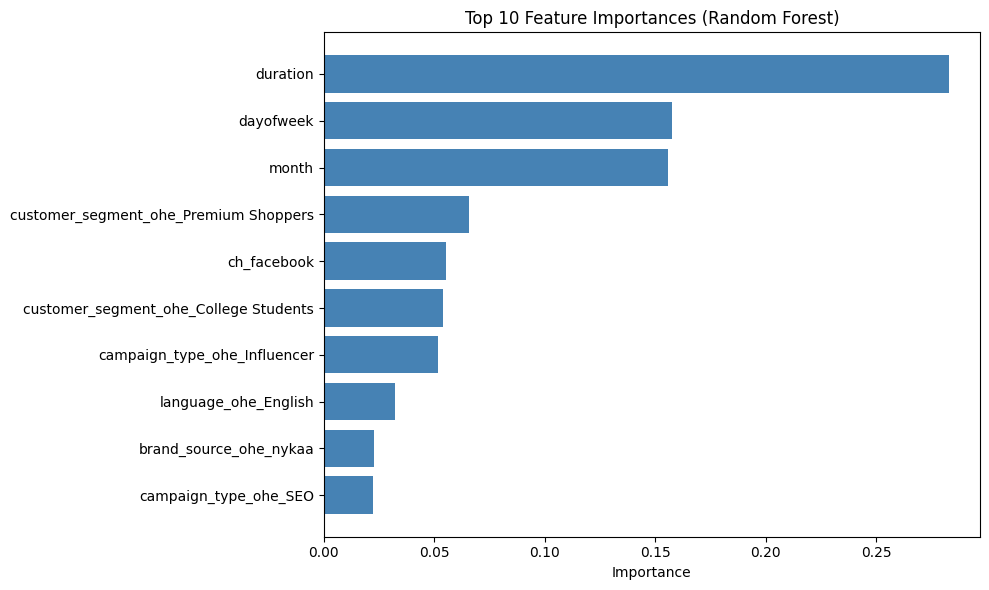

In [ ]:
# Feature importance from the best performing model
best_model_name_map = {
    "Logistic Regression": cv_model_lr,
    "Random Forest":       cv_model_rf,
    "GBT Classifier":      cv_model_gbt
}
best_cv_model = best_model_name_map[best_model_name]
best_stage = best_cv_model.bestModel.stages[-1]

# Extract feature names from VectorAssembler metadata
pred_any = pred_gbt  # use any prediction df to get feature metadata
attrs = pred_any.schema["features"].metadata["ml_attr"]["attrs"]
features_list = []
for key in attrs:
    for a in attrs[key]:
        features_list.append(a)
features_list.sort(key=lambda x: x["idx"])
feature_names = [x["name"] for x in features_list]

# LR uses coefficients, RF and GBT use featureImportances
if best_model_name == "Logistic Regression":
    coef = best_stage.coefficients.toArray()
    importance_df = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": abs(coef)  # absolute value to show magnitude
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    importance_label = "Coefficient Magnitude"
else:
    importance_df = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": best_stage.featureImportances.toArray()
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    importance_label = "Importance"

print(f"Top 10 Feature Importances ({best_model_name}):")
print(importance_df.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"].head(10)[::-1],
    importance_df["Importance"].head(10)[::-1],
    color="steelblue"
)
plt.xlabel(importance_label)
plt.title(f"Top 10 Feature Importances ({best_model_name})")
plt.tight_layout()
plt.show()

## 16. Cleanup

In [ ]:
train_df.unpersist()
test_df.unpersist()
print("Done.")

Done.


# Phase 5

## 1. Install dependencies

In [ ]:
!pip install pyspark mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.5 MB/s eta 0:00:00


## 2. Imports

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from functools import reduce
import re
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.spark
from mlflow.tracking import MlflowClient

## 3. Initialize Spark session

In [ ]:
spark = SparkSession.builder \
    .appName("CampaignClassification_MLOps") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.ansi.enabled", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Spark version: 4.0.2


## 4. GitHub URLs + helper functions

In [ ]:
# GitHub raw URLs for CSV files
urls = {
    "nykaa":   "data/nykaa_campaign_data.csv",
    "purplle": "data/purplle_campaign_data.csv",
    "tira":    "data/tira_campaign_data.csv"
}

def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def parse_dates(pdf: pd.DataFrame, col: str = "date") -> pd.DataFrame:
    def try_parse(val):
        if pd.isnull(val):
            return None
        s = str(val).strip()
        try:
            return pd.to_datetime(s, format="%d-%m-%Y")
        except:
            pass
        try:
            return pd.to_datetime(s, format="%m/%d/%Y")
        except:
            pass
        return None
    pdf[col] = pdf[col].apply(try_parse)
    return pdf

def read_campaign(url: str, brand: str):
    pdf = pd.read_csv(url)
    pdf.columns = [normalize_colname(c) for c in pdf.columns]
    pdf = parse_dates(pdf, "date")
    pdf["brand_source"] = brand
    df = spark.createDataFrame(pdf)
    return df

def align_cols(df, all_cols):
    for c in all_cols:
        if c not in df.columns:
            df = df.withColumn(c, F.lit(None))
    return df.select(all_cols)

def safe_div(num_col, den_col):
    return F.when(
        (den_col.isNotNull()) & (den_col > 0) & (num_col.isNotNull()),
        num_col / den_col
    )

print("Helper functions ready.")

Helper functions ready.


## 5.  Load, clean, and engineer features

In [ ]:
# Load all 3 brand CSVs and union
dfs = [read_campaign(url, brand) for brand, url in urls.items()]
all_cols = sorted(set().union(*[set(d.columns) for d in dfs]))
dfs_aligned = [align_cols(d, all_cols) for d in dfs]
df_all = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs_aligned)
df_all = df_all.dropDuplicates()

# Fill nulls in string columns
string_cols = [c for c, t in df_all.dtypes if t == "string"]
df_all = df_all.fillna({c: "Unknown" for c in string_cols})
for c in string_cols:
    df_all = df_all.withColumn(c, F.trim(F.col(c)))

# Replace negative values with null
nonneg_cols = [c for c, t in df_all.dtypes
               if t in ("int", "bigint", "double", "float", "long")
               and c not in ("roi",)]
for c in nonneg_cols:
    df_all = df_all.withColumn(c, F.when(F.col(c) < 0, None).otherwise(F.col(c)))

# KPI feature engineering
df_feat = (df_all
    .withColumn("ctr",           safe_div(F.col("clicks"),           F.col("impressions")))
    .withColumn("lead_rate",     safe_div(F.col("leads"),            F.col("clicks")))
    .withColumn("lead_to_conv",  safe_div(F.col("conversions"),      F.col("leads")))
    .withColumn("click_to_conv", safe_div(F.col("conversions"),      F.col("clicks")))
    .withColumn("cpc",           safe_div(F.col("acquisition_cost"), F.col("clicks")))
    .withColumn("cpa",           safe_div(F.col("acquisition_cost"), F.col("conversions")))
    .withColumn("roas",          safe_div(F.col("revenue"),          F.col("acquisition_cost")))
    .withColumn("rpm",           safe_div(F.col("revenue").cast("double") * 1000, F.col("impressions")))
)

for col in ["ctr", "lead_rate", "lead_to_conv", "click_to_conv"]:
    df_feat = df_feat.withColumn(
        col, F.when((F.col(col) < 0) | (F.col(col) > 1), None).otherwise(F.col(col))
    )

print(f"Data loaded: {df_feat.count():,} rows")

Data loaded: 166,665 rows


## 6. Create Gold label

In [ ]:
# Define binary label: top 25% ROI → 1 (high-performing), else → 0
q75 = df_feat.approxQuantile("roi", [0.75], 0.01)[0]
print(f"75th percentile ROI threshold: {q75}")

df_gold = df_feat.withColumn(
    "label",
    F.when(F.col("roi") >= q75, 1).otherwise(0)
)

df_gold.groupBy("label").count().orderBy("label").show()

75th percentile ROI threshold: 3.47
+-----+------+
|label| count|
+-----+------+
|    0|123639|
|    1| 43026|
+-----+------+



## 7. Define feature columns

In [ ]:
# Only features available before a campaign runs (no leakage)
categorical_cols = ["brand_source", "campaign_type", "customer_segment", "language"]
numeric_cols     = ["duration", "year", "month", "dayofweek"]
channel_cols     = ["ch_facebook", "ch_whatsapp", "ch_youtube",
                    "ch_google", "ch_email", "ch_instagram"]

# Add date features
df_gold = df_gold.withColumn("year",      F.year("date")) \
                 .withColumn("month",     F.month("date")) \
                 .withColumn("dayofweek", F.dayofweek("date"))

# Create channel flag columns using contains() for multi-channel rows
df_gold = df_gold.withColumn("channel_used_lc", F.lower(F.col("channel_used")))
for ch in ["facebook", "whatsapp", "youtube", "google", "email", "instagram"]:
    df_gold = df_gold.withColumn(
        f"ch_{ch}",
        F.when(F.col("channel_used_lc").contains(ch), 1).otherwise(0)
    )
df_gold = df_gold.drop("channel_used_lc")

for c in numeric_cols:
    df_gold = df_gold.withColumn(c, F.col(c).cast("double"))

print("Categorical:", categorical_cols)
print("Numeric:",     numeric_cols)
print("Channels:",    channel_cols)

Categorical: ['brand_source', 'campaign_type', 'customer_segment', 'language']
Numeric: ['duration', 'year', 'month', 'dayofweek']
Channels: ['ch_facebook', 'ch_whatsapp', 'ch_youtube', 'ch_google', 'ch_email', 'ch_instagram']


## 8. Build Spark ML pipeline stages

In [ ]:
# StringIndexer for each categorical column
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in categorical_cols
]

# OneHotEncoder
encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in categorical_cols],
    outputCols=[c + "_ohe" for c in categorical_cols]
)
ohe_cols = [c + "_ohe" for c in categorical_cols]

# VectorAssembler
assembler = VectorAssembler(
    inputCols=numeric_cols + channel_cols + ohe_cols,
    outputCol="features",
    handleInvalid="keep"
)

print("Pipeline stages defined.")

Pipeline stages defined.


## 9.  Train/test split

In [ ]:
# Split into 80% train, 20% test
train_df, test_df = df_gold.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()
print(f"Train: {train_df.count():,}  |  Test: {test_df.count():,}")

Train: 133,643  |  Test: 33,022


## 10. Evaluator helper + MLflow experiment setup

In [ ]:
# Helper to compute AUC, Precision, Recall, F1
def evaluate_model(pred_df):
    auc_eval  = BinaryClassificationEvaluator(
        labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    prec_eval = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
    rec_eval  = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="weightedRecall")
    f1_eval   = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1")
    return {
        "AUC":       round(auc_eval.evaluate(pred_df),  4),
        "Precision": round(prec_eval.evaluate(pred_df), 4),
        "Recall":    round(rec_eval.evaluate(pred_df),  4),
        "F1":        round(f1_eval.evaluate(pred_df),   4),
    }

# Set up local MLflow experiment
mlflow.set_experiment("Campaign_ROI_Classification")
print("MLflow experiment set:", "Campaign_ROI_Classification")

2026/03/05 08:29:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/05 08:29:05 INFO mlflow.store.db.utils: Updating database tables
2026/03/05 08:29:08 INFO mlflow.tracking.fluent: Experiment with name 'Campaign_ROI_Classification' does not exist. Creating a new experiment.


MLflow experiment set: Campaign_ROI_Classification


## 11. Logistic Regression

In [ ]:
# Logistic Regression
lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=50)
pipeline_lr = Pipeline(stages=indexers + [encoder, assembler, lr])
paramGrid_lr = (ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1])
    .addGrid(lr.elasticNetParam, [0.0,  0.5])
    .build()
)
cv_lr = CrossValidator(
    estimator=pipeline_lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3,
    seed=42
)

with mlflow.start_run(run_name="LogisticRegression_CV"):
    cv_model_lr = cv_lr.fit(train_df)
    pred_lr     = cv_model_lr.bestModel.transform(test_df)
    metrics_lr  = evaluate_model(pred_lr)

    best_lr = cv_model_lr.bestModel.stages[-1]
    mlflow.log_param("model",           "LogisticRegression")
    mlflow.log_param("regParam",        best_lr._java_obj.getRegParam())
    mlflow.log_param("elasticNetParam", best_lr._java_obj.getElasticNetParam())
    for k, v in metrics_lr.items():
        mlflow.log_metric(k, v)
    mlflow.spark.log_model(cv_model_lr.bestModel, artifact_path="spark_model")
    print(f"LR → {metrics_lr}")

LR → {'AUC': 0.5007, 'Precision': 0.5554, 'Recall': 0.7453, 'F1': 0.6365}


## 12. Random Forest

In [ ]:
# Random Forest
rf = RandomForestClassifier(labelCol="label", featuresCol="features")
pipeline_rf = Pipeline(stages=indexers + [encoder, assembler, rf])
paramGrid_rf = (ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [3,  5])
    .build()
)
cv_rf = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3,
    seed=42
)

with mlflow.start_run(run_name="RandomForest_CV"):
    cv_model_rf = cv_rf.fit(train_df)
    pred_rf     = cv_model_rf.bestModel.transform(test_df)
    metrics_rf  = evaluate_model(pred_rf)

    best_rf = cv_model_rf.bestModel.stages[-1]
    mlflow.log_param("model",    "RandomForest")
    mlflow.log_param("numTrees", best_rf._java_obj.getNumTrees())
    mlflow.log_param("maxDepth", best_rf._java_obj.getMaxDepth())
    for k, v in metrics_rf.items():
        mlflow.log_metric(k, v)
    mlflow.spark.log_model(cv_model_rf.bestModel, artifact_path="spark_model")
    print(f"RF → {metrics_rf}")

RF → {'AUC': 0.5061, 'Precision': 0.5554, 'Recall': 0.7453, 'F1': 0.6365}


## 13. GBT

In [ ]:
# GBT
gbt = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20)
pipeline_gbt = Pipeline(stages=indexers + [encoder, assembler, gbt])
paramGrid_gbt = (ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3,    5])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build()
)
cv_gbt = CrossValidator(
    estimator=pipeline_gbt,
    estimatorParamMaps=paramGrid_gbt,
    evaluator=BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC"),
    numFolds=3,
    seed=42
)

with mlflow.start_run(run_name="GBT_CV"):
    cv_model_gbt = cv_gbt.fit(train_df)
    pred_gbt     = cv_model_gbt.bestModel.transform(test_df)
    metrics_gbt  = evaluate_model(pred_gbt)

    best_gbt = cv_model_gbt.bestModel.stages[-1]
    mlflow.log_param("model",    "GBTClassifier")
    mlflow.log_param("maxDepth", best_gbt._java_obj.getMaxDepth())
    mlflow.log_param("stepSize", best_gbt._java_obj.getStepSize())
    for k, v in metrics_gbt.items():
        mlflow.log_metric(k, v)
    mlflow.spark.log_model(cv_model_gbt.bestModel, artifact_path="spark_model")
    print(f"GBT → {metrics_gbt}")

GBT → {'AUC': 0.4999, 'Precision': 0.6481, 'Recall': 0.7452, 'F1': 0.6367}


## 14. Model comparison

In [ ]:
# Compare all three models
comparison = pd.DataFrame({
    "Model":     ["Logistic Regression", "Random Forest", "GBT Classifier"],
    "AUC":       [metrics_lr["AUC"],       metrics_rf["AUC"],       metrics_gbt["AUC"]],
    "Precision": [metrics_lr["Precision"], metrics_rf["Precision"], metrics_gbt["Precision"]],
    "Recall":    [metrics_lr["Recall"],    metrics_rf["Recall"],    metrics_gbt["Recall"]],
    "F1":        [metrics_lr["F1"],        metrics_rf["F1"],        metrics_gbt["F1"]],
})

print("=" * 60)
print("              Model Comparison")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)

# Identify best model by AUC
best_model_name = comparison.loc[comparison["AUC"].idxmax(), "Model"]
best_auc        = comparison["AUC"].max()
print(f"\nBest model: {best_model_name} (AUC: {best_auc:.4f})")

# Log summary to MLflow
with mlflow.start_run(run_name="Model_Comparison_Summary"):
    mlflow.log_metric("LR_AUC",  metrics_lr["AUC"])
    mlflow.log_metric("RF_AUC",  metrics_rf["AUC"])
    mlflow.log_metric("GBT_AUC", metrics_gbt["AUC"])
    mlflow.log_param("best_model", best_model_name)

              Model Comparison
              Model    AUC  Precision  Recall     F1
Logistic Regression 0.5007     0.5554  0.7453 0.6365
      Random Forest 0.5061     0.5554  0.7453 0.6365
     GBT Classifier 0.4999     0.6481  0.7452 0.6367

Best model: Random Forest (AUC: 0.5061)


## 15. Feature importance

Top 10 Feature Importances (Random Forest):
                              Feature  Importance
                             duration    0.247557
                                month    0.129201
                 language_ohe_English    0.117885
                   language_ohe_Tamil    0.085832
                campaign_type_ohe_SEO    0.079149
               brand_source_ohe_nykaa    0.066371
                             ch_email    0.058388
         campaign_type_ohe_Influencer    0.057465
customer_segment_ohe_College Students    0.036980
           customer_segment_ohe_Youth    0.033996


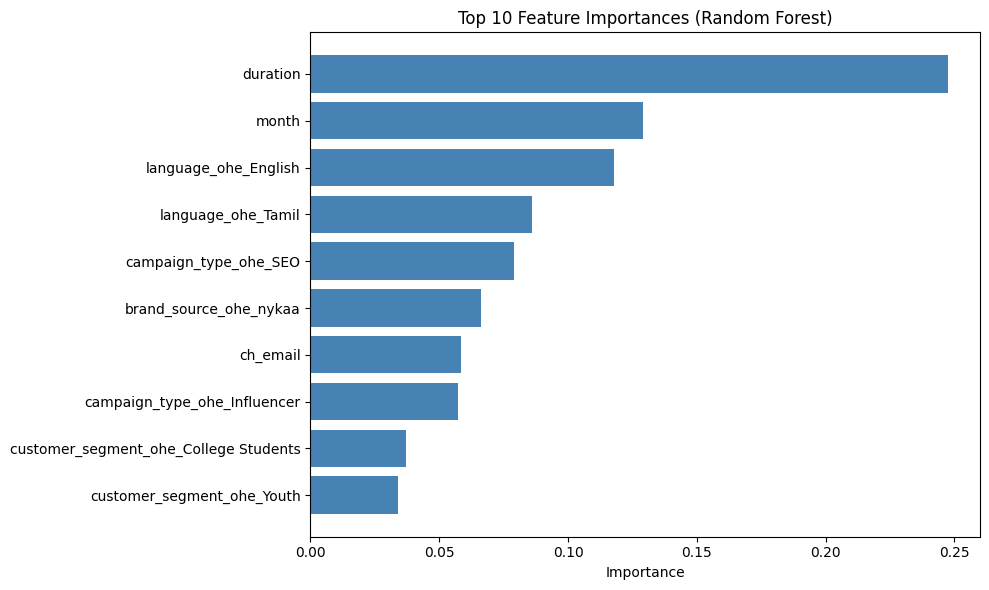

In [ ]:
# Feature importance from the best performing model
best_model_name_map = {
    "Logistic Regression": cv_model_lr,
    "Random Forest":       cv_model_rf,
    "GBT Classifier":      cv_model_gbt
}
best_cv_model = best_model_name_map[best_model_name]
best_stage    = best_cv_model.bestModel.stages[-1]

# Extract feature names from VectorAssembler metadata
attrs = pred_gbt.schema["features"].metadata["ml_attr"]["attrs"]
features_list = []
for key in attrs:
    for a in attrs[key]:
        features_list.append(a)
features_list.sort(key=lambda x: x["idx"])
feature_names = [x["name"] for x in features_list]

# LR uses coefficient magnitude, RF and GBT use featureImportances
if best_model_name == "Logistic Regression":
    coef = best_stage.coefficients.toArray()
    importance_df = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": abs(coef)
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    importance_label = "Coefficient Magnitude"
else:
    importance_df = pd.DataFrame({
        "Feature":    feature_names,
        "Importance": best_stage.featureImportances.toArray()
    }).sort_values("Importance", ascending=False).reset_index(drop=True)
    importance_label = "Importance"

print(f"Top 10 Feature Importances ({best_model_name}):")
print(importance_df.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"].head(10)[::-1],
    importance_df["Importance"].head(10)[::-1],
    color="steelblue"
)
plt.xlabel(importance_label)
plt.title(f"Top 10 Feature Importances ({best_model_name})")
plt.tight_layout()
plt.show()

## 16. View MLflow runs

In [ ]:
# Display all logged runs for this experiment
runs = mlflow.search_runs(experiment_names=["Campaign_ROI_Classification"])
print(runs[["run_id", "tags.mlflow.runName",
            "metrics.AUC", "metrics.F1",
            "params.model"]].to_string(index=False))

                          run_id      tags.mlflow.runName  metrics.AUC  metrics.F1       params.model
487ca901e77a47f9bde3f811ce676500 Model_Comparison_Summary          NaN         NaN               None
ba4b6504f625453ca7d742d53c51b719                   GBT_CV       0.4999      0.6367      GBTClassifier
18dcd487780a427b92d3b1f3fe851dac          RandomForest_CV       0.5061      0.6365       RandomForest
51a6b7cec6cd407c8d9492a06d3a15b6    LogisticRegression_CV       0.5007      0.6365 LogisticRegression


## 17. Register best model + load and re-score

In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Find best run by AUC across all runs in this experiment
runs = mlflow.search_runs(
    experiment_names=["Campaign_ROI_Classification"],
    order_by=["metrics.AUC DESC"]
)

# Filter to runs that logged a spark_model artifact
model_runs = runs[runs["tags.mlflow.log-model.history"].str.contains("spark_model", na=False)]
best_run = model_runs.iloc[0]

print(f"Best run ID  : {best_run['run_id']}")
print(f"Run name     : {best_run['tags.mlflow.runName']}")
print(f"Model        : {best_run['params.model']}")
print(f"AUC          : {best_run['metrics.AUC']:.4f}")
print(f"F1           : {best_run['metrics.F1']:.4f}")

# Load best model from MLflow
model_uri = f"runs:/{best_run['run_id']}/spark_model"
loaded_model = mlflow.spark.load_model(model_uri)
print(f"\nLoaded model from: {model_uri}")

# Re-score test set with loaded model to verify
pred_loaded = loaded_model.transform(test_df)
metrics_loaded = evaluate_model(pred_loaded)
print(f"Loaded model metrics: {metrics_loaded}")

Best run ID  : 18dcd487780a427b92d3b1f3fe851dac
Run name     : RandomForest_CV
Model        : RandomForest
AUC          : 0.5061
F1           : 0.6365


2026/03/05 08:46:02 INFO mlflow.spark: URI 'runs:/18dcd487780a427b92d3b1f3fe851dac/spark_model/sparkml' does not point to the current DFS.
2026/03/05 08:46:02 INFO mlflow.spark: File 'runs:/18dcd487780a427b92d3b1f3fe851dac/spark_model/sparkml' not found on DFS. Will attempt to upload the file.



Loaded model from: runs:/18dcd487780a427b92d3b1f3fe851dac/spark_model
Loaded model metrics: {'AUC': 0.5047, 'Precision': 0.5535, 'Recall': 0.744, 'F1': 0.6347}


## 18. Cleanup

In [ ]:
# Unpersist cached DataFrames
train_df.unpersist()
test_df.unpersist()
print("Done.")

Done.
